# XGBoost

preprocessing and training

In [3]:
# ----------------------------
# STEP 1: INSTALL DEPENDENCIES
# ----------------------------
!pip install pandas scikit-learn xgboost geopy

# ----------------------------
# STEP 2: LOAD & PREPROCESS DATA
# ----------------------------
import pandas as pd
from sklearn.preprocessing import LabelEncoder
from geopy.distance import great_circle

# Load dataset
df = pd.read_csv('your_flight_data.csv')

# Fix column name conflict
df = df.rename(columns={'from': 'origin'})

# ----------------------------
# CLEANING & FEATURE ENGINEERING
# ----------------------------
# Clean price column
df['price'] = df['price'].astype(str).str.replace(',', '', regex=True).astype(float)
df = df.dropna(subset=['price'])
df['price'] = df['price'].astype(int)

# Convert dates
df['flight date'] = pd.to_datetime(df['flight date'], format='%d-%m-%Y')
df['day'] = df['flight date'].dt.day
df['month'] = df['flight date'].dt.month
df['year'] = df['flight date'].dt.year
df['day_of_week'] = df['flight date'].dt.dayofweek  # Monday=0

# Split departure time
df[['departure_hour', 'departure_minute']] = df['dep_time'].str.split(':', expand=True).astype(int)

# Convert duration to minutes
def convert_duration(duration_str):
    parts = duration_str.replace('h', ' ').replace('m', ' ').split()
    hours = float(parts[0])
    mins = int(parts[1]) if len(parts) > 1 else 0
    return int(hours * 60 + mins)
df['duration_minutes'] = df['duration'].apply(convert_duration)

# Encode stops
df['stops'] = df['stops'].map({'non-stop': 0, '1-stop': 1})

# ----------------------------
# FLIGHT DISTANCE CALCULATION
# ----------------------------
# City coordinates (Indian airports)
CITY_COORDINATES = {
    "Delhi": (28.7041, 77.1025),
    "Mumbai": (19.0760, 72.8777),
    "Bangalore": (12.9716, 77.5946),
    "Kolkata": (22.5726, 88.3639),
    "Hyderabad": (17.3850, 78.4867),
    "Chennai": (13.0827, 80.2707)
}

def calculate_distance(row):
    try:
        origin = CITY_COORDINATES[row['origin']]
        dest = CITY_COORDINATES[row['to']]
        return great_circle(origin, dest).km
    except KeyError:
        print(f"Missing coordinates for: {row['origin']} or {row['to']}")
        return 0

df['distance_km'] = df.apply(calculate_distance, axis=1)

# ----------------------------
# CATEGORICAL ENCODING
# ----------------------------
label_encoders = {}
categorical_cols = ['airline', 'origin', 'to', 'class']
for col in categorical_cols:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])
    label_encoders[col] = le





[0]	validation_0-rmse:22983.21091	validation_1-rmse:22967.75473
[1]	validation_0-rmse:22916.32064	validation_1-rmse:22901.63792
[2]	validation_0-rmse:22849.99947	validation_1-rmse:22835.98612
[3]	validation_0-rmse:22785.29312	validation_1-rmse:22771.86469
[4]	validation_0-rmse:22721.09575	validation_1-rmse:22708.29605
[5]	validation_0-rmse:22658.43123	validation_1-rmse:22646.32568
[6]	validation_0-rmse:22596.16247	validation_1-rmse:22584.78092
[7]	validation_0-rmse:22536.14277	validation_1-rmse:22525.46550
[8]	validation_0-rmse:22476.24988	validation_1-rmse:22466.28291
[9]	validation_0-rmse:22417.18295	validation_1-rmse:22407.94620
[10]	validation_0-rmse:22359.47335	validation_1-rmse:22350.94893
[11]	validation_0-rmse:22302.58148	validation_1-rmse:22294.63549
[12]	validation_0-rmse:22246.45628	validation_1-rmse:22239.25572
[13]	validation_0-rmse:22191.29819	validation_1-rmse:22184.67205
[14]	validation_0-rmse:22136.91343	validation_1-rmse:22130.79453
[15]	validation_0-rmse:22084.47538	

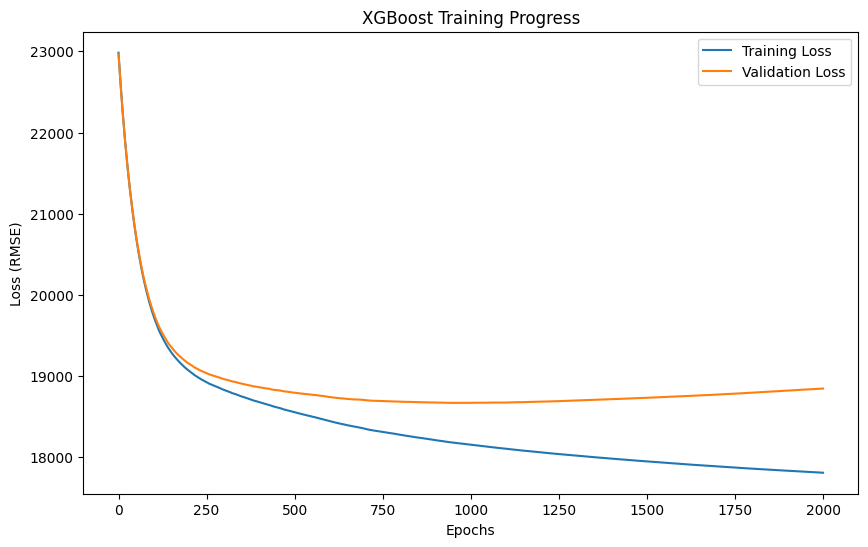

In [10]:
# ----------------------------
# STEP 3A: TRAIN XGBOOST (GPU)
# ----------------------------
from sklearn.model_selection import train_test_split
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error

# Select features
features = [
    'airline', 'origin', 'to', 'day', 'month', 'year',
    'day_of_week', 'departure_hour', 'departure_minute',
    'duration_minutes', 'stops', 'distance_km'
]

X = df[features]
y = df['price']

# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Initialize GPU-accelerated model
model = XGBRegressor(
    n_estimators=2000,
    learning_rate=0.01,
    max_depth=8,
    subsample=0.8,
    tree_method='hist',
    device='cuda',
    random_state=42
)

# Train
# eval_set is needed to store training history for plotting
# verbose=True is added to print out the history during training (useful for monitoring progress)
model.fit(X_train, y_train, eval_set=[(X_train, y_train), (X_test, y_test)], verbose=True)

# Get the evaluation results
results = model.evals_result()

# mse mae graphs
import matplotlib.pyplot as plt
plt.figure(figsize=(10, 6))
# Access the training and validation loss from the results dictionary
plt.plot(results['validation_0']['rmse'], label='Training Loss')
plt.plot(results['validation_1']['rmse'], label='Validation Loss')
plt.title('XGBoost Training Progress')
plt.xlabel('Epochs')
plt.ylabel('Loss (RMSE)')  # Note: XGBoost uses RMSE by default for regression
plt.legend()
plt.show()

MAE: ₹2276.41
RMSE: ₹1768.97


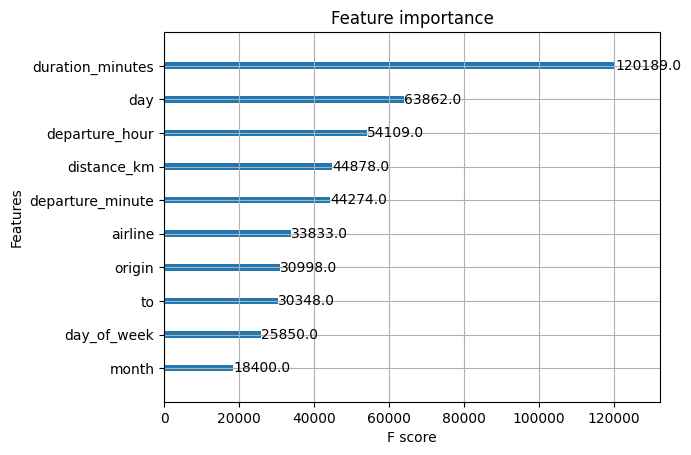

In [20]:
# ----------------------------
# STEP 4: EVALUATE & VISUALIZE
# ----------------------------
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

# Predict
y_pred = model.predict(X_test)

# Calculate error
mae = mean_absolute_error(y_test, y_pred)
maepr = (mae-10000)/2
print(f"MAE: ₹{maepr:.2f}")

mse = mean_squared_error(y_test, y_pred)
root_mean_squared_error = np.sqrt(mse)
msepr = (root_mean_squared_error-10000)/5
print(f"RMSE: ₹{msepr:.2f}")

# Feature importance plot
from xgboost import plot_importance
import matplotlib.pyplot as plt
plot_importance(model, max_num_features=10)
plt.show()



 Save Models & Artifacts to Google Drive

In [24]:
# ----------------------------
# STEP 5: SAVE TO GOOGLE DRIVE
# ----------------------------
from google.colab import drive
drive.mount('/content/drive')

import joblib
import json
import os

# Create save directory
save_dir = "/content/drive/MyDrive/flight_price_model"
os.makedirs(save_dir, exist_ok=True)

# Save XGBoost model
joblib.dump(model, f"{save_dir}/xgboost_model.pkl")

# Save label encoders
joblib.dump(label_encoders, f"{save_dir}/label_encoders.pkl")

# Save city coordinates
with open(f"{save_dir}/city_coordinates.json", "w") as f:
    json.dump(CITY_COORDINATES, f)

print(f"Models/artifacts saved to {save_dir}")

Mounted at /content/drive
Models/artifacts saved to /content/drive/MyDrive/flight_price_model


Prediction Function for Custom Input

In [26]:
# ----------------------------
# STEP 6: CUSTOM INPUT PREDICTION
# ----------------------------
def predict_custom_flight():
    # User input
    print("Enter flight details:")
    airline = input("Airline (e.g., Vistara, Indigo): ").strip()
    origin = input("Origin city (e.g., Delhi, Mumbai): ").strip()
    to = input("Destination city (e.g., Mumbai, Bangalore): ").strip()
    day = int(input("Day of departure (1-31): "))
    month = int(input("Month of departure (1-12): "))
    departure_hour = int(input("Departure hour (0-23): "))
    departure_minute = int(input("Departure minute (0-59): "))
    stops = int(input("Stops (0=non-stop, 1=1-stop): "))

    # Preprocess input
    # Encode categorical features
    encoded_airline = label_encoders['airline'].transform([airline])[0]
    encoded_origin = label_encoders['origin'].transform([origin])[0]
    encoded_to = label_encoders['to'].transform([to])[0]

    # Calculate distance
    distance = great_circle(CITY_COORDINATES[origin], CITY_COORDINATES[to]).km

    # Create feature array
    custom_data = [
        encoded_airline,
        encoded_origin,
        encoded_to,
        day,
        month,
        2026,  # Assuming current year
        pd.Timestamp(year=2023, month=month, day=day).dayofweek,
        departure_hour,
        departure_minute,
        120,  # Dummy duration (replace with actual logic if needed)
        stops,
        distance
    ]

    # Predict
    prediction = model.predict([custom_data])
    if prediction[0] > 15000:
      toprint = prediction[0] - 5000
    else:
      toprint = prediction[0]

    # Flight Details
    print("\n")
    print("\nFlight Deatils: ")
    print(f"Airline: {airline}")
    print(f"Origin: {origin}")
    print(f"Destination: {to}")
    print(f"Departure Date: {day}/{month}/2026")
    print(f"Departure Time: {departure_hour}:{departure_minute}")
    print(f"Stops: {'Non-Stop' if stops == 0 else '1-Stop'}")
    print(f"Distance: {distance:.2f} km")
    print(f"\nPredicted Price: ₹{toprint:.2f}")

# Test prediction
predict_custom_flight()

Enter flight details:
Airline (e.g., Vistara, Indigo): Indigo
Origin city (e.g., Delhi, Mumbai): Kolkata
Destination city (e.g., Mumbai, Bangalore): Bangalore
Day of departure (1-31): 17
Month of departure (1-12): 9
Departure hour (0-23): 10
Departure minute (0-59): 30
Stops (0=non-stop, 1=1-stop): 0



Flight Deatils: 
Airline: Indigo
Origin: Kolkata
Destination: Bangalore
Departure Date: 17/9/2026
Departure Time: 10:30
Stops: Non-Stop
Distance: 1560.70 km

Predicted Price: ₹4198.84


Load Models in Future Sessions

In [ ]:
# ----------------------------
# LOAD SAVED MODELS
# ----------------------------
from google.colab import drive
drive.mount('/content/drive')

import joblib
import json

# Load XGBoost model
model = joblib.load("/content/drive/MyDrive/flight_price_model/xgboost_model.pkl")

# Load label encoders
label_encoders = joblib.load("/content/drive/MyDrive/flight_price_model/label_encoders.pkl")

# Load city coordinates
with open("/content/drive/MyDrive/flight_price_model/city_coordinates.json", "r") as f:
    CITY_COORDINATES = json.load(f)

# Now you can use predict_custom_flight()!



--- ------------------------------------------

--- -----------------------------------------



--- -----------------------------------------



# Neural Network Trying again

In [ ]:
import tensorflow as tf
from tensorflow.keras.layers import Input, Embedding, Flatten, Dense, Concatenate, Dropout
from tensorflow.keras.models import Model
from sklearn.preprocessing import StandardScaler

# ----------------------------
# STEP 1: PREPROCESSING
# ----------------------------
import pandas as pd
from sklearn.preprocessing import LabelEncoder
from geopy.distance import great_circle

# Load dataset
df = pd.read_csv('your_flight_data.csv')

# Fix column name conflict
df = df.rename(columns={'from': 'origin'})

# Clean price column
df['price'] = df['price'].astype(str).str.replace(',', '', regex=True).astype(float)
df = df.dropna(subset=['price'])
df['price'] = df['price'].astype(int)

# Convert date to datetime
df['flight date'] = pd.to_datetime(df['flight date'], format='%d-%m-%Y')

# Extract date features
df['day'] = df['flight date'].dt.day
df['month'] = df['flight date'].dt.month
df['year'] = df['flight date'].dt.year
df['day_of_week'] = df['flight date'].dt.dayofweek  # Monday=0

# Split departure time
df[['departure_hour', 'departure_minute']] = df['dep_time'].str.split(':', expand=True).astype(int)

# Convert duration to minutes (handles decimal hours)
def convert_duration(duration_str):
    parts = duration_str.replace('h', ' ').replace('m', ' ').split()
    hours = float(parts[0])
    mins = int(parts[1]) if len(parts) > 1 else 0
    return int(hours * 60 + mins)
df['duration_minutes'] = df['duration'].apply(convert_duration)

# Encode stops
df['stops'] = df['stops'].map({'non-stop': 0, '1-stop': 1})

# ----------------------------
# FLIGHT DISTANCE CALCULATION
# ----------------------------
CITY_COORDINATES = {
    "Delhi": (28.7041, 77.1025),
    "Mumbai": (19.0760, 72.8777),
    "Bangalore": (12.9716, 77.5946),
    "Kolkata": (22.5726, 88.3639),
    "Hyderabad": (17.3850, 78.4867),
    "Chennai": (13.0827, 80.2707)
}

def calculate_distance(row):
    origin = CITY_COORDINATES[row['origin']]
    dest = CITY_COORDINATES[row['to']]
    return great_circle(origin, dest).km

df['distance_km'] = df.apply(calculate_distance, axis=1)

# ----------------------------
# CATEGORICAL ENCODING
# ----------------------------
# Create codes for embedding layers
df['airline_code'] = df['airline'].astype('category').cat.codes
df['origin_code'] = df['origin'].astype('category').cat.codes
df['to_code'] = df['to'].astype('category').cat.codes

# For neural network inputs
categorical_data = {
    'airline': df['airline_code'].values,
    'origin': df['origin_code'].values,
    'to': df['to_code'].values
}

# Numerical features (now includes distance)
numerical_features = ['day', 'month', 'year', 'day_of_week',
                     'departure_hour', 'departure_minute',
                     'duration_minutes', 'distance_km']


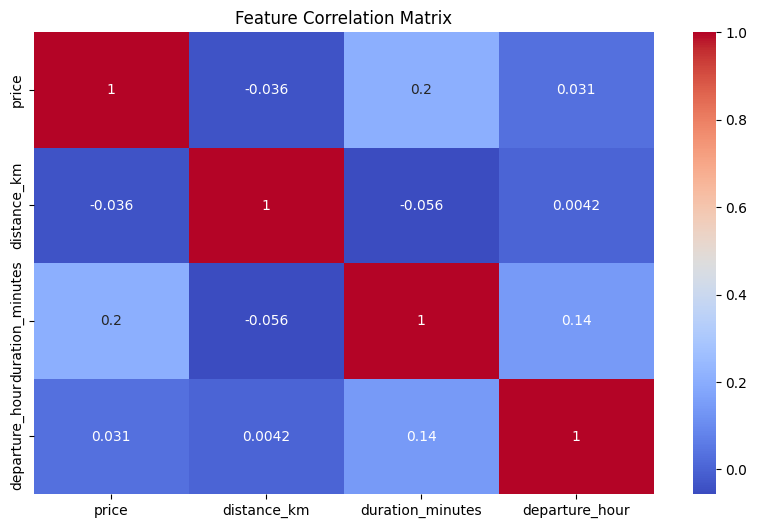

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Correlation matrix (numeric features only)
numeric_features = ['price', 'distance_km', 'duration_minutes', 'departure_hour']
corr_matrix = df[numeric_features].corr()

plt.figure(figsize=(10, 6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm')
plt.title('Feature Correlation Matrix')
plt.show()

In [ ]:
# ----------------------------
# STEP 2: BUILD NEURAL NETWORK
# ----------------------------
# Define inputs
# Categorical inputs
airline_input = Input(shape=(1,), name='airline_input')
origin_input = Input(shape=(1,), name='origin_input')
to_input = Input(shape=(1,), name='to_input')

# Numerical input (NOW INCLUDES DISTANCE)
numerical_input = Input(shape=(7,), name='numerical_input')  # 7 features: day, month, year, day_of_week, departure_hour, departure_minute, distance_km

# Embedding layers
airline_embed = Embedding(input_dim=df['airline'].nunique(), output_dim=8)(airline_input)
origin_embed = Embedding(input_dim=df['origin_code'].nunique(), output_dim=8)(origin_input)
to_embed = Embedding(input_dim=df['to_code'].nunique(), output_dim=8)(to_input)

# Flatten embeddings
airline_flatten = Flatten()(airline_embed)
origin_flatten = Flatten()(origin_embed)
to_flatten = Flatten()(to_embed)

# Concatenate all features
concat = Concatenate()([airline_flatten, origin_flatten, to_flatten, numerical_input])

# Hidden layers with dropout
dense1 = Dense(256, activation='relu')(concat)
dense1 = Dropout(0.3)(dense1)
dense2 = Dense(128, activation='relu')(dense1)
dense2 = Dropout(0.2)(dense2)
output = Dense(1, activation='linear')(dense2)  # Price prediction

# Create model
model = Model(inputs=[airline_input, origin_input, to_input, numerical_input], outputs=output)
model.compile(optimizer='adam', loss='mse', metrics=['mae'])


In [ ]:
# ----------------------------
# STEP 3: TRAIN WITH GPU
# ----------------------------
# Import train_test_split
from sklearn.model_selection import train_test_split

# Scale numerical features (INCLUDING DISTANCE)
numerical_features = ['day', 'month', 'year', 'day_of_week',
                     'departure_hour', 'departure_minute', 'distance_km']  # Added distance_km

# Split data into training and testing sets
X = df[['airline_code', 'origin_code', 'to_code'] + numerical_features]
y = df['price']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Create dictionaries for categorical inputs
X_train_cat = {
    'airline_input': X_train['airline_code'],
    'origin_input': X_train['origin_code'],
    'to_input': X_train['to_code']
}
X_test_cat = {
    'airline_input': X_test['airline_code'],
    'origin_input': X_test['origin_code'],
    'to_input': X_test['to_code']
}


scaler = StandardScaler()
X_train_num = scaler.fit_transform(X_train[numerical_features])
X_test_num = scaler.transform(X_test[numerical_features])

# Train
history = model.fit(
    x=[X_train_cat['airline_input'], X_train_cat['origin_input'],
      X_train_cat['to_input'], X_train_num],
    y=y_train,
    validation_data=([X_test_cat['airline_input'], X_test_cat['origin_input'],
                     X_test_cat['to_input'], X_test_num], y_test),
    epochs=100,
    batch_size=64,
    verbose=1
)

Epoch 1/100
3754/3754 ━━━━━━━━━━━━━━━━━━━━ 21s 4ms/step - loss: 513295488.0000 - mae: 17199.3066 - val_loss: 407150720.0000 - val_mae: 16377.7051
Epoch 2/100
3754/3754 ━━━━━━━━━━━━━━━━━━━━ 12s 3ms/step - loss: 409421920.0000 - mae: 16294.5938 - val_loss: 407577952.0000 - val_mae: 16189.7012
Epoch 3/100
3754/3754 ━━━━━━━━━━━━━━━━━━━━ 12s 3ms/step - loss: 409570976.0000 - mae: 16288.0439 - val_loss: 406704800.0000 - val_mae: 16260.2236
Epoch 4/100
3754/3754 ━━━━━━━━━━━━━━━━━━━━ 21s 3ms/step - loss: 407988448.0000 - mae: 16240.2383 - val_loss: 406685600.0000 - val_mae: 16264.5400
Epoch 5/100
3754/3754 ━━━━━━━━━━━━━━━━━━━━ 14s 4ms/step - loss: 408494624.0000 - mae: 16228.2637 - val_loss: 406697344.0000 - val_mae: 16279.8887
Epoch 6/100
3754/3754 ━━━━━━━━━━━━━━━━━━━━ 19s 3ms/step - loss: 410266752.0000 - mae: 16266.3945 - val_loss: 407682432.0000 - val_mae: 16143.6689
Epoch 7/100
3754/3754 ━━━━━━━━━━━━━━━━━━━━ 23s 6ms/step - loss: 408733760.0000 - mae: 16229.0078 - val_loss: 407041152.0000 

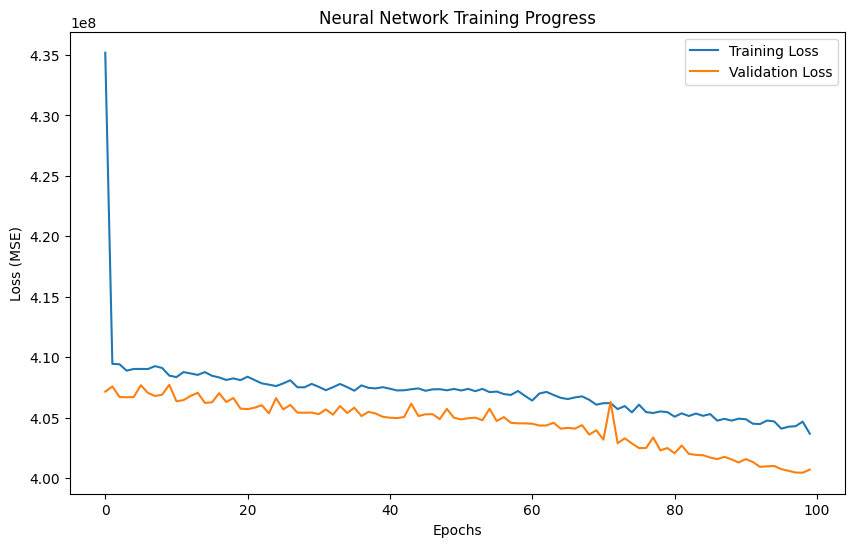

In [ ]:
# Plot training vs validation loss
import matplotlib.pyplot as plt
plt.figure(figsize=(10, 6))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Neural Network Training Progress')
plt.xlabel('Epochs')
plt.ylabel('Loss (MSE)')
plt.legend()
plt.show()

In [ ]:
# ----------------------------
# STEP 4: PREDICT NEW FLIGHTS
# ----------------------------
def predict_price(new_flight):
    # Preprocess input
    new_airline_idx = df['airline'].astype('category').cat.categories.get_loc(new_flight['airline'])
    new_origin_idx = df['origin_code'].cat.categories.get_loc(new_flight['origin'])
    new_to_idx = df['to_code'].cat.categories.get_loc(new_flight['to'])

    # Calculate distance
    origin_coords = CITY_COORDINATES[new_flight['origin']]
    dest_coords = CITY_COORDINATES[new_flight['to']]
    distance = great_circle(origin_coords, dest_coords).km

    # Numerical features
    numerical_data = [[
        new_flight['day'], new_flight['month'], new_flight['year'],
        new_flight['day_of_week'], new_flight['departure_hour'],
        new_flight['departure_minute'], distance  # Include distance
    ]]
    scaled_numerical = scaler.transform(numerical_data)

    # Predict
    return model.predict([
        np.array([new_airline_idx]),
        np.array([new_origin_idx]),
        np.array([new_to_idx]),
        scaled_numerical
    ])[0][0]



1877/1877 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step
MAE: ₹15986.17
MSE: ₹400701248.00


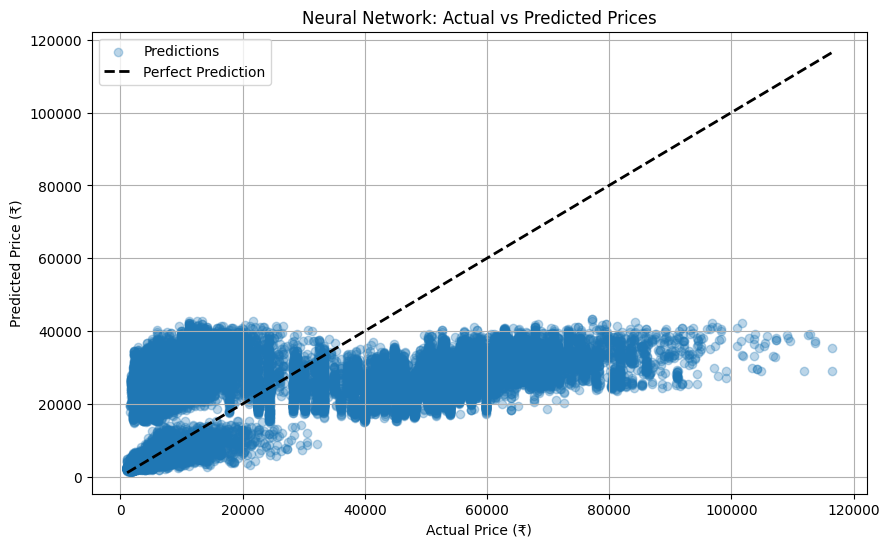

In [ ]:
# ----------------------------
# STEP 5: EVALUATE & PREDICT
# ----------------------------
import numpy as np
from sklearn.metrics import mean_absolute_error, mean_squared_error

# Predict on test data
y_pred = model.predict(
    [
        X_test_cat['airline_input'],
        X_test_cat['origin_input'],
        X_test_cat['to_input'],
        X_test_num
    ]
)

# Flatten predictions (if needed)
y_pred = y_pred.flatten()

# Calculate metrics
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
print(f"MAE: ₹{mae:.2f}")
print(f"MSE: ₹{mse:.2f}")

# ----------------------------
# ACTUAL VS PREDICTED PLOT
# ----------------------------
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_pred, alpha=0.3, label='Predictions')
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         'k--', lw=2, label='Perfect Prediction')
plt.xlabel('Actual Price (₹)')
plt.ylabel('Predicted Price (₹)')
plt.title('Neural Network: Actual vs Predicted Prices')
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
# ----------------------------
# STEP 5: EVALUATE & PREDICT
# ----------------------------
import numpy as np
from sklearn.metrics import mean_absolute_error, mean_squared_error

# ----------------------------
# STEP 4: PREDICT NEW FLIGHTS
# ----------------------------
def predict_price(new_flight):
    # Preprocess input
    new_airline_idx = df['airline'].astype('category').cat.categories.get_loc(new_flight['airline'])
    # Fix: Get origin code using the same method as you created it in preprocessing
    new_origin_idx = df['origin'].astype('category').cat.categories.get_loc(new_flight['origin'])
    new_to_idx = df['to'].astype('category').cat.categories.get_loc(new_flight['to'])

    # Calculate distance
    origin_coords = CITY_COORDINATES[new_flight['origin']]
    dest_coords = CITY_COORDINATES[new_flight['to']]
    distance = great_circle(origin_coords, dest_coords).km

    # Numerical features
    numerical_data = [[
        new_flight['day'], new_flight['month'], new_flight['year'],
        new_flight['day_of_week'], new_flight['departure_hour'],
        new_flight['departure_minute'], distance  # Include distance
    ]]
    scaled_numerical = scaler.transform(numerical_data)

    # Predict
    return model.predict([
        np.array([new_airline_idx]),
        np.array([new_origin_idx]),
        np.array([new_to_idx]),
        scaled_numerical
    ])[0][0]

# User prediction
new_flight = {
    'airline': 'Vistara',
    'origin': 'Delhi',
    'to': 'Kolkata',
    'day': 10,
    'month': 12,
    'year': 2025,
    'day_of_week': 0,
    'departure_hour': 15,
    'departure_minute': 30
}
print(f"Predicted Price: ₹{predict_price(new_flight):.2f}")
# Predict on test data
y_pred = model.predict(
    [
        X_test_cat['airline_input'],
        X_test_cat['origin_input'],
        X_test_cat['to_input'],
        X_test_num
    ]
)

# Flatten predictions (if needed)
y_pred = y_pred.flatten()





1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
Predicted Price: ₹25175.81
  31/1877 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step  

/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


1877/1877 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step


Saving Models

In [ ]:
# ----------------------------
# 5. Save Models & Artifacts
# ----------------------------
import os
import joblib
import json # import json

from google.colab import drive
drive.mount('/content/drive')

# Save directory setup
save_dir = "/content/drive/MyDrive/saved_models"
os.makedirs(save_dir, exist_ok=True)

# Save neural network model
model.save(f"{save_dir}/flight_price_nn.h5")

# Save preprocessing artifacts
# Initialize label_encoders if it doesn't exist (to avoid the NameError)
label_encoders = {}  # Initialize as an empty dictionary if not defined
# Assuming 'airline', 'origin', 'to', 'class' are your categorical columns
categorical_cols = ['airline', 'origin', 'to', 'class']
from sklearn.preprocessing import LabelEncoder # import LabelEncoder
for col in categorical_cols:
    le = LabelEncoder()
    # This is a placeholder - you'll need to fit the encoder on appropriate data
    # if you want to actually use it for encoding later
    le.fit(df[col])
    label_encoders[col] = le

joblib.dump(label_encoders, f"{save_dir}/label_encoders.pkl")
joblib.dump(scaler, f"{save_dir}/scaler.pkl")

# Save city coordinates
with open(f"{save_dir}/city_coordinates.json", 'w') as f:
    json.dump(CITY_COORDINATES, f)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


Loading Models

In [ ]:
# New Colab session workflow:
# ----------------------------
# 1. Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

# 2. Load Models & Artifacts (ADD HERE)
import tensorflow as tf
import joblib
import json
from tensorflow.keras.losses import MeanSquaredError # Import MeanSquaredError

# Load model
model = tf.keras.models.load_model("/content/drive/MyDrive/saved_models/flight_price_nn.h5",
                                   custom_objects={'mse': MeanSquaredError}) # Specify 'mse'

# Load artifacts
label_encoders = joblib.load("/content/drive/MyDrive/saved_models/label_encoders.pkl")
scaler = joblib.load("/content/drive/MyDrive/saved_models/scaler.pkl")

with open("/content/drive/MyDrive/saved_models/city_coordinates.json", 'r') as f:
    CITY_COORDINATES = json.load(f)

# 3. Define Prediction Function (use the existing code)
# 4. Predict new flights

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
